<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2014/try_it_14_1_required.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Try-It Activity 14.1: Grid Searching Decision Trees

This try-it focuses on performing a grid search with a `DecisionTreeClassifier`.  As mentioned in the lectures, the grid search for a tree model can get large very easily. In addition to using `GridSearchCV`, scikitlearn implements additional tools that can save energy and offer alternatives to the brute force exhaustive search.  Below, you will compare the performance of some of these alternatives and discuss the time these searches take.  Note that this will be in large part determined by your personal computing power however the relative speed of the searches should be consistent.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_halving_search_cv
from sklearn.tree import DecisionTreeClassifier,export_text, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV, HalvingRandomSearchCV
from timeit import default_timer as timer

In [45]:
# Load the data
diabetes = pd.read_csv("/content/sample_data/diabetes.csv")
diabetes.head()

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0


In [46]:
diabetes.describe()

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.502922e+06,3.224533,107.856867,71.220667,28.814000,137.852133,31.509646,0.398968,30.137733,0.333333
std,2.892534e+05,3.391020,31.981975,16.758716,14.555716,133.068252,9.759000,0.377944,12.089703,0.471420
min,1.000038e+06,0.000000,44.000000,24.000000,7.000000,14.000000,18.200512,0.078044,21.000000,0.000000
25%,1.252866e+06,0.000000,84.000000,58.000000,15.000000,39.000000,21.259887,0.137743,22.000000,0.000000
50%,1.505508e+06,2.000000,104.000000,72.000000,31.000000,83.000000,31.767940,0.200297,24.000000,0.000000
75%,1.755205e+06,6.000000,129.000000,85.000000,41.000000,195.000000,39.259692,0.616285,35.000000,1.000000
max,1.999997e+06,14.000000,192.000000,117.000000,93.000000,799.000000,56.034628,2.301594,77.000000,1.000000


In [47]:
X =diabetes.drop(columns = {"Diabetic"})
y= diabetes["Diabetic"]
# Train - test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
params = {'max_depth': [3,5,7,9],
          'min_samples_split': [3,4,5],
          'criterion': ['gini','entropy'],
          'min_samples_leaf': [2,3,4,5]
         }

In [49]:
dtree = DecisionTreeClassifier()

### Comparing Grid Searches

Below, explore the four grid search options using the same parameter selections for the `DecisionTreeClassifier`. All of the grid searching tools have a `.cv_results_` attribute after fitting that contains information after fitting including time.  Use this to compare the time of each search and discuss what you believe the "best" approach to identifying the hyperparameters of the model are between:

- `GridSearchCV`
- `RandomizedSearchCV`
- `HalvingGridSearchCV`
- `HalvingRandomSearchCV`

Share your results in a plot comparing the different times for searching across the different parameters as well as the score of the different estimators that resulted from the grid search.  

In [50]:
grid_estimators = list()

grids_results= list()
grids_time= list()

GridSearchCV

In [51]:
grid = GridSearchCV(dtree, params, cv=5)
start = timer()
grid.fit(X_train, y_train)
end = timer()

print(grid.best_params_)
print(f'Time to run GridSearchCV: {end-start}')
grids_time.append(end-start)
grid.best_estimator_
grid.best_score_

grids_results.append(grid.best_score_)
grid_estimators.append('GridSearchCV')

{'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 3}
Time to run GridSearchCV: 31.04791423000006


In [52]:
#This refers to the average time taken to train (fit) a single model for a specific set of hyperparameters across all cross-validation folds.
#So, for each unique combination of max_depth, min_samples_split, criterion, and min_samples_leaf that GridSearchCV evaluates,
#it trains the model cv (in your case, 5) times. mean_fit_time is the average of those 5 training times.

5* grid.cv_results_['mean_fit_time'].sum() # comes close to the value in the timer() function.

# While the time taken to train the model may be taken as mean time for each cross validation split multiplied by the mean time from cv_results ,
# until the entire grid search process is completed, we cannot know the best estimator or the best params . Hence, we will consider the timer() function only for calculating the time of each search.
# There isnt a single function provided by cv_results for the consolidated time.

np.float64(29.23737263679504)

HalvingGridSearchCV

In [53]:
halfgrid = HalvingGridSearchCV(dtree, params, cv=5)
start = timer()
halfgrid.fit(X_train, y_train)
end = timer()

print(halfgrid.best_params_)
print(f'Time to run HalvingGridSearchCV: {end-start}')
halfgrid.best_estimator_
halfgrid.best_score_

grids_results.append(halfgrid.best_score_)
grids_time.append(end-start)
grid_estimators.append('HalvingGridSearchCV')

{'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 5}
Time to run HalvingGridSearchCV: 7.601629419999881


In [54]:
5*halfgrid.cv_results_['mean_fit_time'].sum() # comes close to the value in the timer() function.

np.float64(4.231759786605835)

#RandomizedSearchCV

In [55]:
randomizedgrid = RandomizedSearchCV(dtree, params, cv=5)
start = timer()
randomizedgrid.fit(X_train, y_train)
end = timer()

print(randomizedgrid.best_params_)
print(f'Time to run RandomizedSearchCV: {end-start}')
randomizedgrid.best_estimator_
randomizedgrid.best_score_

grids_results.append(randomizedgrid.best_score_)
grids_time.append(end-start)
grid_estimators.append('RandomizedSearchCV')

{'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 9, 'criterion': 'entropy'}
Time to run RandomizedSearchCV: 3.5830202570004985


In [56]:
5*randomizedgrid.cv_results_['mean_fit_time'].sum() # comes close to the value in the timer() function.

np.float64(3.2929229736328125)

In [57]:
randomizedgrid.best_estimator_


DecisionTreeClassifier(criterion='entropy', max_depth=9, min_samples_leaf=5,
                       min_samples_split=5)

In [58]:
halfrandomizedgrid = HalvingRandomSearchCV(dtree, params, cv=5)
start = timer()
halfrandomizedgrid.fit(X_train, y_train)
end = timer()

print(halfrandomizedgrid.best_params_)
print(f'Time to run HalvingRandomSearchCV: {end-start}')
halfrandomizedgrid.best_estimator_
halfrandomizedgrid.best_score_

grids_results.append(halfrandomizedgrid.best_score_)
grids_time.append(end-start)
grid_estimators.append('HalvingRandomSearchCV')

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 96 is smaller than n_iter=600. Running 96 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'min_samples_split': 3, 'min_samples_leaf': 2, 'max_depth': 7, 'criterion': 'entropy'}
Time to run HalvingRandomSearchCV: 4.847755845999927


In [59]:
5*halfrandomizedgrid.cv_results_['mean_fit_time'].sum() # comes close to the value in the timer() function.

np.float64(1.9110605716705322)

In [60]:
grids_results

[np.float64(0.9147500000000001),
 np.float64(0.913892365456821),
 np.float64(0.9120000000000001),
 np.float64(0.8814814814814815)]

In [61]:
grids_time

[31.04791423000006, 7.601629419999881, 3.5830202570004985, 4.847755845999927]

In [62]:
all_grids_metrics= pd.DataFrame(list(zip(grid_estimators,grids_results,grids_time)), columns =['estimators','score','time'])
all_grids_metrics

,estimators,score,time
0,GridSearchCV,0.914750,31.047914
1,HalvingGridSearchCV,0.913892,7.601629
2,RandomizedSearchCV,0.912000,3.583020
3,HalvingRandomSearchCV,0.881481,4.847756


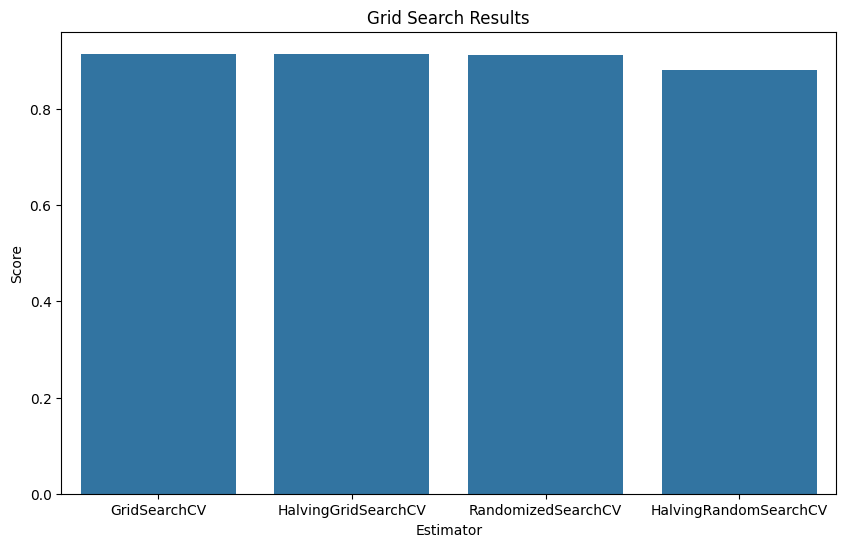

In [63]:
# Now plot the results comparing the different times for searching across the different parameters as well as the score of the different estimators that resulted from the grid search.
plt.figure(figsize=(10, 6))
sns.barplot(x='estimators', y='score', data=all_grids_metrics)
plt.title('Grid Search Results')
plt.xlabel('Estimator')
plt.ylabel('Score')
plt.show()


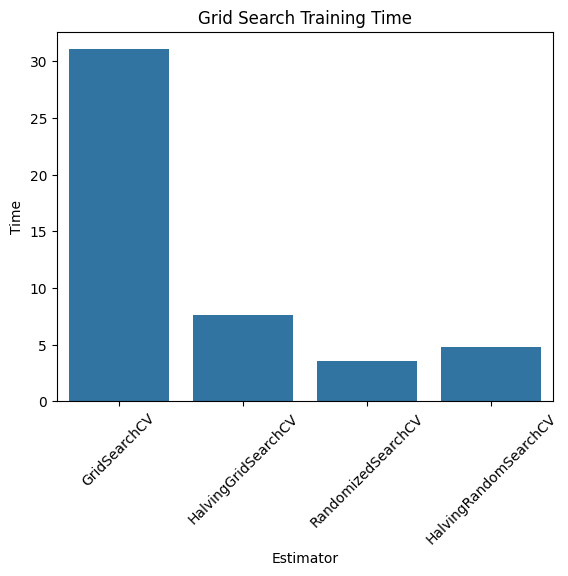

In [64]:
sns.barplot(x='estimators', y='time', data=all_grids_metrics)
plt.title('Grid Search Training Time')
plt.xlabel('Estimator')
plt.ylabel('Time')
plt.xticks(rotation=45)
plt.show()